<a href="https://colab.research.google.com/github/sampozo/Challenge-X2-SP/blob/main/TelecomX2_LATAM_SP_ipnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Fase 1: Carga y Codificación

In [11]:
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Conectar con Google Drive
drive.mount('/content/drive')

# 2. Definir la ruta y cargar los datos (Todo junto para evitar el NameError)
ruta = "/content/drive/MyDrive/ALURA/CIENCIA DE DATOS/CHALLENGE TELECOM X II/datos_tratados.csv"
df = pd.read_csv(ruta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# 3. Preprocesamiento para Machine Learning
# Quitamos el ID porque no es una característica predictiva
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# 4. Transformar texto a números (One-Hot Encoding)
columnas_categoricas = df.select_dtypes(include=['object']).columns.tolist()
# Eliminamos 'Churn' de la lista de categóricas para tratarla aparte si es necesario
if 'Churn' in columnas_categoricas:
    columnas_categoricas.remove('Churn')

df_ml = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)

# 5. Convertir Churn (nuestro objetivo) a 0 y 1
if 'Churn' in df_ml.columns:
    le = LabelEncoder()
    df_ml['Churn'] = le.fit_transform(df_ml['Churn'])

In [13]:
# 6. Definir variables X (datos) y y (respuesta)
X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

# 7. Separar datos: 70% para entrenar, 30% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("✅ ¡Listo! Drive conectado y datos preparados.")
print(f"Columnas finales en el modelo: {X.columns.tolist()}")
display(df_ml.head())

✅ ¡Listo! Drive conectado y datos preparados.
Columnas finales en el modelo: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Cuentas_Diarias', 'Churn_Numerico', 'gender_Male', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Bianual', 'Contract_Mes a mes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Cuentas_Diarias,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Bianual,Contract_Mes a mes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,2.19,...,True,False,True,False,False,False,False,False,False,True
1,0,0,0,0,9,1,0,59.9,542.40,2.00,...,False,False,False,False,True,False,True,False,False,True
2,1,0,0,0,4,1,1,73.9,280.85,2.46,...,False,False,False,False,False,False,True,False,True,False
3,1,1,1,0,13,1,1,98.0,1237.85,3.27,...,False,False,True,False,True,False,True,False,True,False
4,1,1,1,0,3,1,1,83.9,267.40,2.80,...,True,False,True,False,False,False,True,False,False,True


In [ ]:
#Verificación de la Proporción de Cancelación (Churn):

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la proporción real
conteo_churn = df_ml['Churn'].value_counts()
proporcion_churn = df_ml['Churn'].value_counts(normalize=True) * 100

print("--- Análisis de Proporción de Churn (Desbalance) ---")
print(f"Clientes que se QUEDAN (0): {conteo_churn[0]} ({proporcion_churn[0]:.2f}%)")
print(f"Clientes que se VAN (1):    {conteo_churn[1]} ({proporcion_churn[1]:.2f}%)")

--- Análisis de Proporción de Churn (Desbalance) ---
Clientes que se QUEDAN (0): 5174 (73.46%)
Clientes que se VAN (1):    1869 (26.54%)


/tmp/ipykernel_175/3720950540.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proporcion_churn.index, y=proporcion_churn.values, palette='viridis')


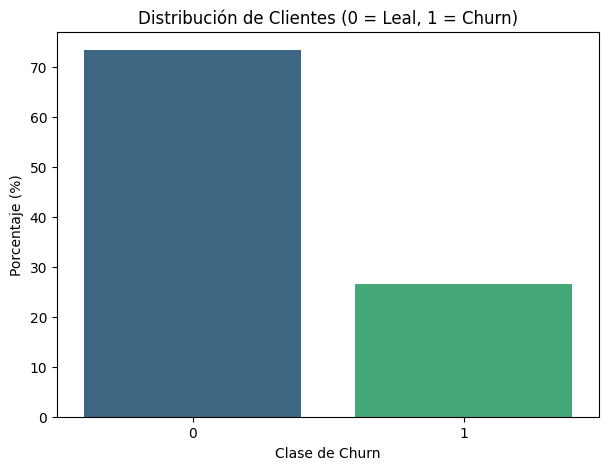

✅ BALANCE: La proporción es manejable para los modelos de clasificación.


In [15]:
# 2. Gráfico visual para el reporte
plt.figure(figsize=(7, 5))
sns.barplot(x=proporcion_churn.index, y=proporcion_churn.values, palette='viridis')
plt.title('Distribución de Clientes (0 = Leal, 1 = Churn)')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Clase de Churn')
plt.show()

# 3. Conclusión técnica
if proporcion_churn[1] < 20:
    print("⚠️ ALERTA: Existe un desbalance importante. Podríamos necesitar técnicas de balanceo (como SMOTE) más adelante.")
else:
    print("✅ BALANCE: La proporción es manejable para los modelos de clasificación.")

In [ ]:
# Balanceo de Clases



In [16]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [17]:
# 1. Mostrar estado inicial
print(f"Distribución original antes de SMOTE: {Counter(y_train)}")

# 2. Aplicar SMOTE solo sobre los datos de entrenamiento (X_train, y_train)
# ¡OJO! Nunca se aplica sobre los datos de prueba (X_test) para no contaminar el examen.
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Mostrar resultado del balanceo
print(f"Nueva distribución después de SMOTE: {Counter(y_train_res)}")

# 4. Verificación rápida
print("\n✅ Los datos ahora están balanceados 50/50 para el entrenamiento.")

Distribución original antes de SMOTE: Counter({0: 3622, 1: 1308})
Nueva distribución después de SMOTE: Counter({0: 3622, 1: 3622})

✅ Los datos ahora están balanceados 50/50 para el entrenamiento.


In [ ]:
# NORMALIZACION Y ESTANDARIZACION


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
# 1. Inicializar el escalador
scaler = StandardScaler()

# 2. Ajustar y transformar los datos de entrenamiento balanceados (X_train_res)
# Solo usamos 'fit' en el entrenamiento para aprender la escala
X_train_scaled = scaler.fit_transform(X_train_res)

# 3. Transformar los datos de prueba (X_test)
# ¡Importante! Usamos la escala que aprendió de los datos de entrenamiento
X_test_scaled = scaler.transform(X_test)

print("✅ Normalización (StandardScaler) completada.")
print(f"Ejemplo de datos escalados (primeras 2 filas):\n{X_train_scaled[:2]}")

✅ Normalización (StandardScaler) completada.
Ejemplo de datos escalados (primeras 2 filas):
[[-0.39786768 -0.76901782 -0.52538183 -0.5618371   0.32835141 -1.24095606
   0.29004748 -0.42142761  0.29176822 -1.          0.86686255 -0.32835141
  -0.97545303  0.91650405 -0.45423349 -0.45423349 -0.62119321 -0.45423349
  -0.75724132 -0.45423349  1.29156493 -0.45423349 -0.63294448 -0.45423349
  -0.89278927 -0.45423349 -0.90005275 -0.46371167  0.68532423 -0.52752038
   1.04000442 -0.55438727]
 [-0.39786768 -0.76901782 -0.52538183 -0.93774823  0.32835141  0.8058303
   0.06481458 -0.77464759  0.06132259  1.          0.86686255 -0.32835141
  -0.97545303 -1.09110265 -0.45423349 -0.45423349 -0.62119321 -0.45423349
  -0.75724132 -0.45423349  1.29156493 -0.45423349 -0.63294448 -0.45423349
   1.12008514 -0.45423349  1.11104599 -0.46371167 -1.45916334 -0.52752038
  -0.96153437  1.80379322]]


In [ ]:
#  Correlación y Selección de Variables

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [21]:
# 1. Calcular la matriz de correlación de Pearson
# Usamos df_ml porque necesitamos las variables ya convertidas a números
corr_matrix = df_ml.corr()

In [22]:
# 2. Extraer la correlación específica con la variable objetivo 'Churn'
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)

print("--- Top 5 Variables con mayor correlación POSITIVA con Churn ---")
print(churn_corr.head(6)) # El primero será Churn mismo (1.0)
print("\n--- Top 5 Variables con mayor correlación NEGATIVA con Churn ---")
print(churn_corr.tail(5))

--- Top 5 Variables con mayor correlación POSITIVA con Churn ---
Churn                             1.000000
Churn_Numerico                    1.000000
Contract_Mes a mes                0.405103
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
Cuentas_Diarias                   0.193412
Name: Churn, dtype: float64

--- Top 5 Variables con mayor correlación NEGATIVA con Churn ---
DeviceProtection_No internet service   -0.227890
StreamingMovies_No internet service    -0.227890
TechSupport_No internet service        -0.227890
Contract_Bianual                       -0.302253
tenure                                 -0.352229
Name: Churn, dtype: float64


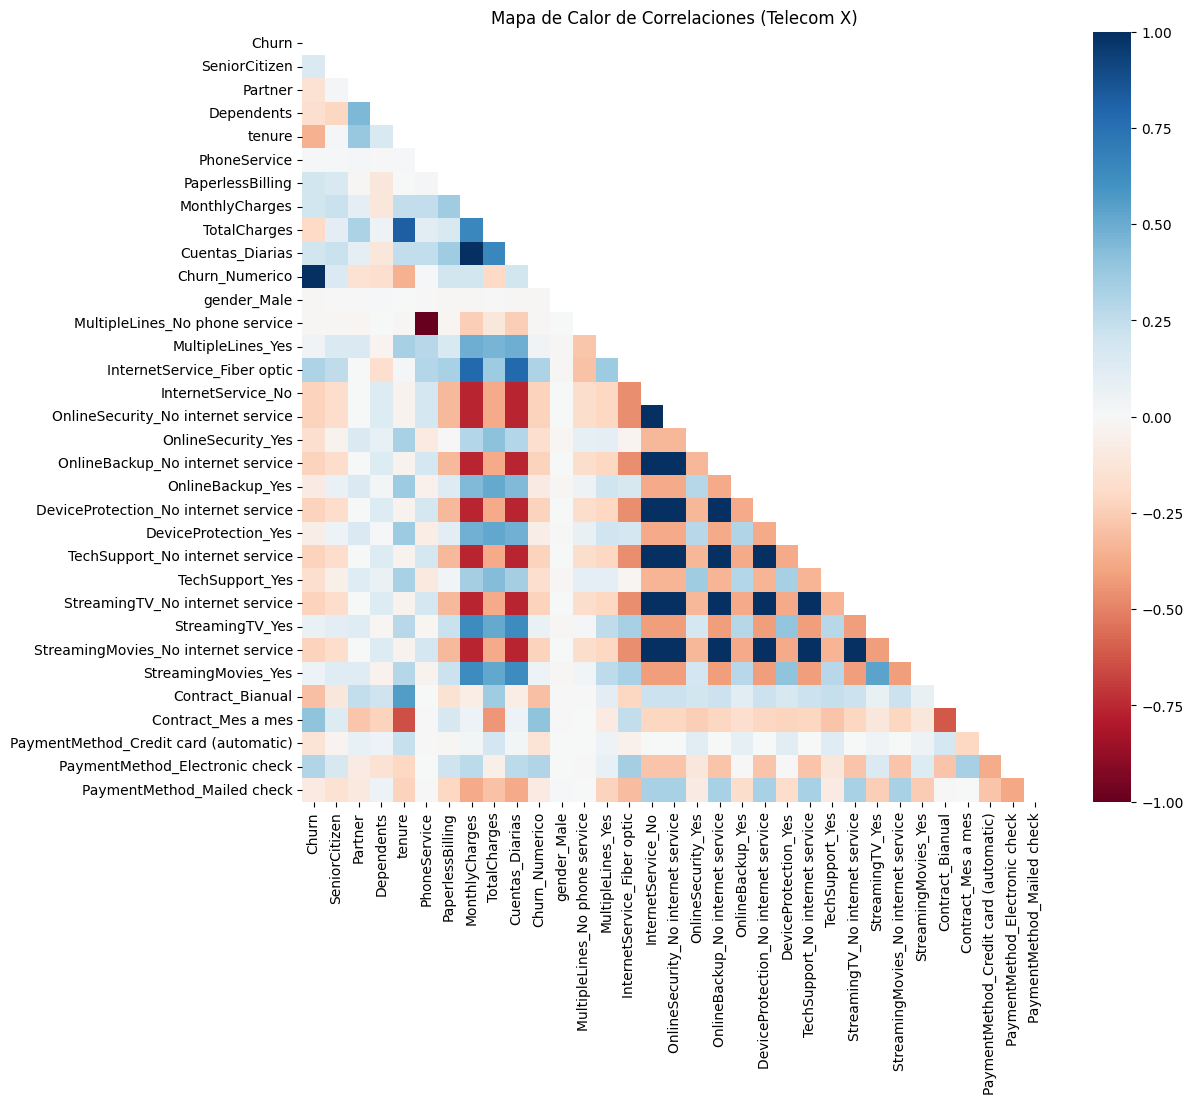

In [23]:
# 3. Dibujar el Heatmap para ver el panorama general
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Para ver solo la mitad y no repetir
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu', center=0)
plt.title('Mapa de Calor de Correlaciones (Telecom X)')
plt.show()